In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Intraday correlation/cointegration pairs strategy between HNGSNGBEES.NS (NSE) and 2800.HK (HKEX).

Notes:
- Yahoo Finance 1m data typically covers only ~7 calendar days. Use period="5d"/"7d" or exact recent dates.
- NSE and HKEX have partial overlap in trading hours. This script only trades in the overlapping window.
- Optional FX: HKD/INR ("HKDINR=X"). If available, convert 2800.HK (HKD) to INR to reduce currency noise.
- Signals: z-score of cointegration spread. Enter when |z|>=entry_z, exit at |z|<=exit_z, risk filters apply.
- This is a simple research script, not investment advice. Slippage/fees/taxes not included.
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
from datetime import datetime, timedelta, timezone

# ----------------------- Parameters -----------------------
TICKER_NSE = "HNGSNGBEES.NS"
TICKER_HK  = "2800.HK"
TICKER_FX  = "HKDINR=X"       # optional FX to convert HKD to INR

# Yahoo intraday constraints: 1m resolution for up to ~7 days
PERIOD       = "7d"           # "1d","5d","7d"
INTERVAL     = "1m"           # "1m" is needed for intraday signals

# Trading window (overlap of HKEX and NSE) in UTC times.
# HKEX: ~01:30–08:00 UTC (09:30–16:00 HKT, no DST). Lunch often abolished for equities; use continuous.
# NSE:  03:45–10:00 UTC (09:15–15:30 IST).
# Overlap is roughly 03:45–08:00 UTC. We'll use a slightly conservative window.
OVERLAP_START_UTC = "03:45"
OVERLAP_END_UTC   = "08:00"

# Rolling windows
ROLL_HEDGE_MIN    = 120       # min bars to estimate hedge (e.g., 2 hours of 1-min bars)
ROLL_Z_WINDOW     = 240       # window to compute z-score (e.g., 4 hours)
ROLL_CORR_WINDOW  = 120       # window for correlation filter

# Signal thresholds
ENTRY_Z           = 2.0
EXIT_Z            = 0.5
STOP_Z            = 3.0       # hard stop if z expands
MIN_CORR          = 0.5       # require correlation between the two series >= this

# Positioning
MAX_HOLD_MIN      = 60        # max holding time in minutes
NOTIONAL_PER_TRADE= 1_000_000 # for P&L scaling in INR; adjust to your size

# Use FX conversion?
USE_FX            = True

# Output
OUT_SIGNALS_CSV   = "hsi_pairs_signals.csv"
OUT_PNL_CSV       = "hsi_pairs_pnl.csv"


# ----------------------- Utilities -----------------------
def download_ohlc_1m(ticker: str, period: str = PERIOD, interval: str = INTERVAL) -> pd.DataFrame:
    df = yf.download(ticker, period=period, interval=interval, auto_adjust=False, progress=False)
    if df.empty:
        raise RuntimeError(f"Empty data for {ticker}. Yahoo may have no intraday data or throttle applied.")
    # Ensure UTC tz
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    else:
        df.index = df.index.tz_convert("UTC")
    df.columns = [c.lower() for c in df.columns]
    # Keep essential columns
    df = df[['open', 'high', 'low', 'close', 'volume']]
    return df

def restrict_overlap_window(df: pd.DataFrame, start_utc="03:45", end_utc="08:00") -> pd.DataFrame:
    # Filter times within the UTC daily window
    t1 = pd.to_datetime(start_utc).time()
    t2 = pd.to_datetime(end_utc).time()
    return df.between_time(t1, t2)

def time_align_union(a: pd.DataFrame, b: pd.DataFrame) -> pd.DataFrame:
    # Outer join on index, then ffill to align nearest bar, then drop rows with any remaining NaN
    merged = a[['close']].rename(columns={'close':'close_a'}).join(
        b[['close']].rename(columns={'close':'close_b'}), how='outer'
    ).sort_index()
    merged = merged.ffill()
    merged = merged.dropna()
    return merged

def rolling_ols_beta(y: pd.Series, x: pd.Series, window: int) -> pd.Series:
    # Estimate rolling hedge ratio beta_t from OLS y = alpha + beta x + eps
    betas = pd.Series(index=y.index, dtype=float)
    # Using simple covariance/variance in rolling window
    cov = y.rolling(window).cov(x)
    var = x.rolling(window).var()
    betas = cov / var
    return betas

def compute_spread(y: pd.Series, x: pd.Series, beta: pd.Series) -> pd.Series:
    # spread_t = y_t - beta_t * x_t
    # Ensure alignment
    beta = beta.reindex(y.index).ffill()
    spread = y - beta * x
    return spread

def zscore(series: pd.Series, window: int) -> pd.Series:
    mu = series.rolling(window).mean()
    sd = series.rolling(window).std(ddof=1)
    return (series - mu) / sd

def rolling_corr(a: pd.Series, b: pd.Series, window: int) -> pd.Series:
    return a.rolling(window).corr(b)

def add_fx_conversion(hk_close_hkd: pd.Series, fx_hkdinr: pd.Series) -> pd.Series:
    # Convert HKD price to INR using HKD/INR FX mid price (Yahoo "HKDINR=X")
    fx = fx_hkdinr.reindex(hk_close_hkd.index).ffill()
    return hk_close_hkd * fx

def simulate_trades(ts: pd.DataFrame,
                    entry_z=ENTRY_Z, exit_z=EXIT_Z, stop_z=STOP_Z,
                    min_corr=MIN_CORR, max_hold_min=MAX_HOLD_MIN,
                    notional=NOTIONAL_PER_TRADE):
    """
    ts: DataFrame with columns:
        close_a (INR) -> HNGSNGBEES.NS
        close_b (HKD or INR) -> 2800.HK (converted to INR if USE_FX=True)
        beta, spread, z, corr
    Trading logic (mean reversion):
        - If z >= entry_z and corr>=min_corr: short A, long B (since A is rich vs beta*B)
        - If z <= -entry_z and corr>=min_corr: long A, short B
        - Exit when |z| <= exit_z, or |z| >= stop_z (stop), or max_hold_min elapsed
    Position sizing:
        - Dollar-neutral by hedge ratio: size_A = notional, size_B = beta * notional
    P&L:
        - Simple next-bar close-to-close mark to market.
    """
    records = []
    position = None  # dict with fields: dir (1 long A/short B, -1 short A/long B), entry_time, entry_z, entry_prices

    ts = ts.copy()
    ts['pnl'] = 0.0

    for i in range(1, len(ts)):
        t = ts.index[i]
        row = ts.iloc[i]
        prev = ts.iloc[i-1]

        # Exit conditions
        if position is not None:
            hold_minutes = int((t - position['entry_time']).total_seconds() // 60)
            # mark to market pnl from prev to current (close-close for simplicity)
            # A leg is in INR, B leg is in INR (after conversion if enabled)
            dA = row['close_a'] - prev['close_a']
            dB = row['close_b_inr'] - prev['close_b_inr']

            # Position: dir=+1 means long A, short beta*B
            pnl_step = position['dir'] * (notional * dA - position['beta'] * notional * dB)
            ts.iat[i, ts.columns.get_loc('pnl')] = pnl_step

            # Check exits
            exit_reason = None
            if abs(row['z']) <= exit_z:
                exit_reason = 'take_profit'
            elif abs(row['z']) >= stop_z:
                exit_reason = 'stop'
            elif hold_minutes >= max_hold_min:
                exit_reason = 'time'

            if exit_reason:
                records.append({
                    'entry_time': position['entry_time'],
                    'exit_time': t,
                    'direction': 'longA_shortB' if position['dir']>0 else 'shortA_longB',
                    'entry_z': position['entry_z'],
                    'exit_z': row['z'],
                    'beta': position['beta'],
                    'reason': exit_reason
                })
                position = None

        # Entry conditions (no current position)
        if position is None:
            if (row['corr'] >= min_corr) and np.isfinite(row['z']) and np.isfinite(row['beta']):
                if row['z'] >= entry_z:
                    # A rich -> short A, long B: dir = -1 in our pnl formula
                    position = {
                        'dir': -1,
                        'entry_time': t,
                        'entry_z': row['z'],
                        'beta': row['beta'],
                    }
                elif row['z'] <= -entry_z:
                    # A cheap -> long A, short B: dir = +1
                    position = {
                        'dir': +1,
                        'entry_time': t,
                        'entry_z': row['z'],
                        'beta': row['beta'],
                    }

    # Aggregate P&L
    ts['cum_pnl'] = ts['pnl'].cumsum()
    trades = pd.DataFrame(records)
    return trades, ts


def main():
    print("Downloading 1-minute data from Yahoo...")
    a = download_ohlc_1m(TICKER_NSE, period=PERIOD, interval=INTERVAL)
    b = download_ohlc_1m(TICKER_HK,  period=PERIOD, interval=INTERVAL)

    # Optional FX to convert HKD -> INR
    if USE_FX:
        try:
            fx = download_ohlc_1m(TICKER_FX, period=PERIOD, interval=INTERVAL)
            fx_close = fx['close']
            b_close_inr = add_fx_conversion(b['close'], fx_close)
            print("Applied HKD/INR FX conversion to 2800.HK.")
        except Exception as e:
            print("FX conversion unavailable, proceeding without currency alignment:", e)
            b_close_inr = b['close']
    else:
        b_close_inr = b['close']

    # Keep overlapping UTC window only
    a_win = restrict_overlap_window(a, OVERLAP_START_UTC, OVERLAP_END_UTC)
    b_win = restrict_overlap_window(b, OVERLAP_START_UTC, OVERLAP_END_UTC)
    if USE_FX:
        fx_win = restrict_overlap_window(fx[['close']], OVERLAP_START_UTC, OVERLAP_END_UTC)

    # Align on minute grid using ffill
    merged = time_align_union(a_win, b_win)
    # Add INR-converted HK close aligned
    b_inr = b_close_inr.reindex(merged.index).ffill()
    merged['close_b_inr'] = b_inr
    merged = merged.dropna()

    # Rolling hedge beta of A ~ beta * B
    beta = rolling_ols_beta(merged['close_a'], merged['close_b_inr'], window=ROLL_HEDGE_MIN)
    spread = compute_spread(merged['close_a'], merged['close_b_inr'], beta)
    z = zscore(spread, window=ROLL_Z_WINDOW)
    corr = rolling_corr(merged['close_a'].pct_change(), merged['close_b_inr'].pct_change(), window=ROLL_CORR_WINDOW)

    ts = merged.copy()
    ts['beta'] = beta
    ts['spread'] = spread
    ts['z'] = z
    ts['corr'] = corr

    # Drop warmup
    ts = ts.dropna(subset=['beta','z','corr'])

    # Simulate signals/P&L
    trades, pnl_ts = simulate_trades(ts)

    # Save
    trades.to_csv(OUT_SIGNALS_CSV, index=False)
    pnl_ts[['close_a','close_b_inr','beta','spread','z','corr','pnl','cum_pnl']].to_csv(OUT_PNL_CSV)

    print(f"Saved signals: {OUT_SIGNALS_CSV}")
    print(f"Saved pnl time-series: {OUT_PNL_CSV}")
    if len(trades):
        print("Sample trades:")
        print(trades.head())
    else:
        print("No trades generated with current thresholds; try lowering ENTRY_Z or MIN_CORR.")

if __name__ == "__main__":
    main()


KeyError: "None of [Index(['open', 'high', 'low', 'close', 'volume'], dtype='object')] are in the [columns]"

In [1]:
# Step 1: Import required libraries and read CSV files
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

# Read the CSV files
hk2800_df = pd.read_csv('hk2800_7d_1m.csv')
hngsngbees_df = pd.read_csv('HNGSNGBEES_7d_1m.csv')

print("HK2800 Dataset:")
print(f"Shape: {hk2800_df.shape}")
print(f"Date range: {hk2800_df['Datetime'].min()} to {hk2800_df['Datetime'].max()}")

print("\nHNGSNGBEES Dataset:")
print(f"Shape: {hngsngbees_df.shape}")
print(f"Date range: {hngsngbees_df['Datetime'].min()} to {hngsngbees_df['Datetime'].max()}")

HK2800 Dataset:
Shape: (2220, 9)
Date range: 2025-09-25 09:30:00+08:00 to 2025-10-06 16:08:00+08:00

HNGSNGBEES Dataset:
Shape: (1748, 8)
Date range: 2025-09-26 09:15:00+05:30 to 2025-10-06 15:29:00+05:30


In [2]:
# Step 2: Convert Datetime columns to pandas datetime and set timezone
hk2800_df['Datetime'] = pd.to_datetime(hk2800_df['Datetime'])
hngsngbees_df['Datetime'] = pd.to_datetime(hngsngbees_df['Datetime'])

# Set Datetime as index
hk2800_df.set_index('Datetime', inplace=True)
hngsngbees_df.set_index('Datetime', inplace=True)

print("After datetime conversion:")
print(f"HK2800 timezone: {hk2800_df.index.tz}")
print(f"HNGSNGBEES timezone: {hngsngbees_df.index.tz}")
print(f"HK2800 date range: {hk2800_df.index.min()} to {hk2800_df.index.max()}")
print(f"HNGSNGBEES date range: {hngsngbees_df.index.min()} to {hngsngbees_df.index.max()}")

After datetime conversion:
HK2800 timezone: UTC+08:00
HNGSNGBEES timezone: UTC+05:30
HK2800 date range: 2025-09-25 09:30:00+08:00 to 2025-10-06 16:08:00+08:00
HNGSNGBEES date range: 2025-09-26 09:15:00+05:30 to 2025-10-06 15:29:00+05:30


In [3]:
# Step 3: Find overlapping time frame
# Convert both to UTC for comparison
hk2800_utc = hk2800_df.copy()
hngsngbees_utc = hngsngbees_df.copy()

# Convert to UTC if they have timezone info
if hk2800_utc.index.tz is not None:
    hk2800_utc.index = hk2800_utc.index.tz_convert('UTC')
else:
    # Assume HK timezone and convert to UTC
    hk2800_utc.index = hk2800_utc.index.tz_localize('Asia/Hong_Kong').tz_convert('UTC')

if hngsngbees_utc.index.tz is not None:
    hngsngbees_utc.index = hngsngbees_utc.index.tz_convert('UTC')
else:
    # Assume India timezone and convert to UTC
    hngsngbees_utc.index = hngsngbees_utc.index.tz_localize('Asia/Kolkata').tz_convert('UTC')

# Find overlapping time range
start_overlap = max(hk2800_utc.index.min(), hngsngbees_utc.index.min())
end_overlap = min(hk2800_utc.index.max(), hngsngbees_utc.index.max())

print(f"Overlapping time range (UTC): {start_overlap} to {end_overlap}")
print(f"Duration: {end_overlap - start_overlap}")

# Filter data to overlapping period
hk2800_overlap = hk2800_utc[(hk2800_utc.index >= start_overlap) & (hk2800_utc.index <= end_overlap)]
hngsngbees_overlap = hngsngbees_utc[(hngsngbees_utc.index >= start_overlap) & (hngsngbees_utc.index <= end_overlap)]

print(f"\nHK2800 overlapping data points: {len(hk2800_overlap)}")
print(f"HNGSNGBEES overlapping data points: {len(hngsngbees_overlap)}")

Overlapping time range (UTC): 2025-09-26 03:45:00+00:00 to 2025-10-06 08:08:00+00:00
Duration: 10 days 04:23:00

HK2800 overlapping data points: 1773
HNGSNGBEES overlapping data points: 1637


Available dates in the overlapping period:
  2025-09-26
  2025-09-29
  2025-09-30
  2025-10-01
  2025-10-02
  2025-10-03
  2025-10-06
\n==================================================
USAGE: Call plot_daily_pct_changes('YYYY-MM-DD')
Example: plot_daily_pct_changes('2025-09-26')
\nExample plot for 2025-09-26:


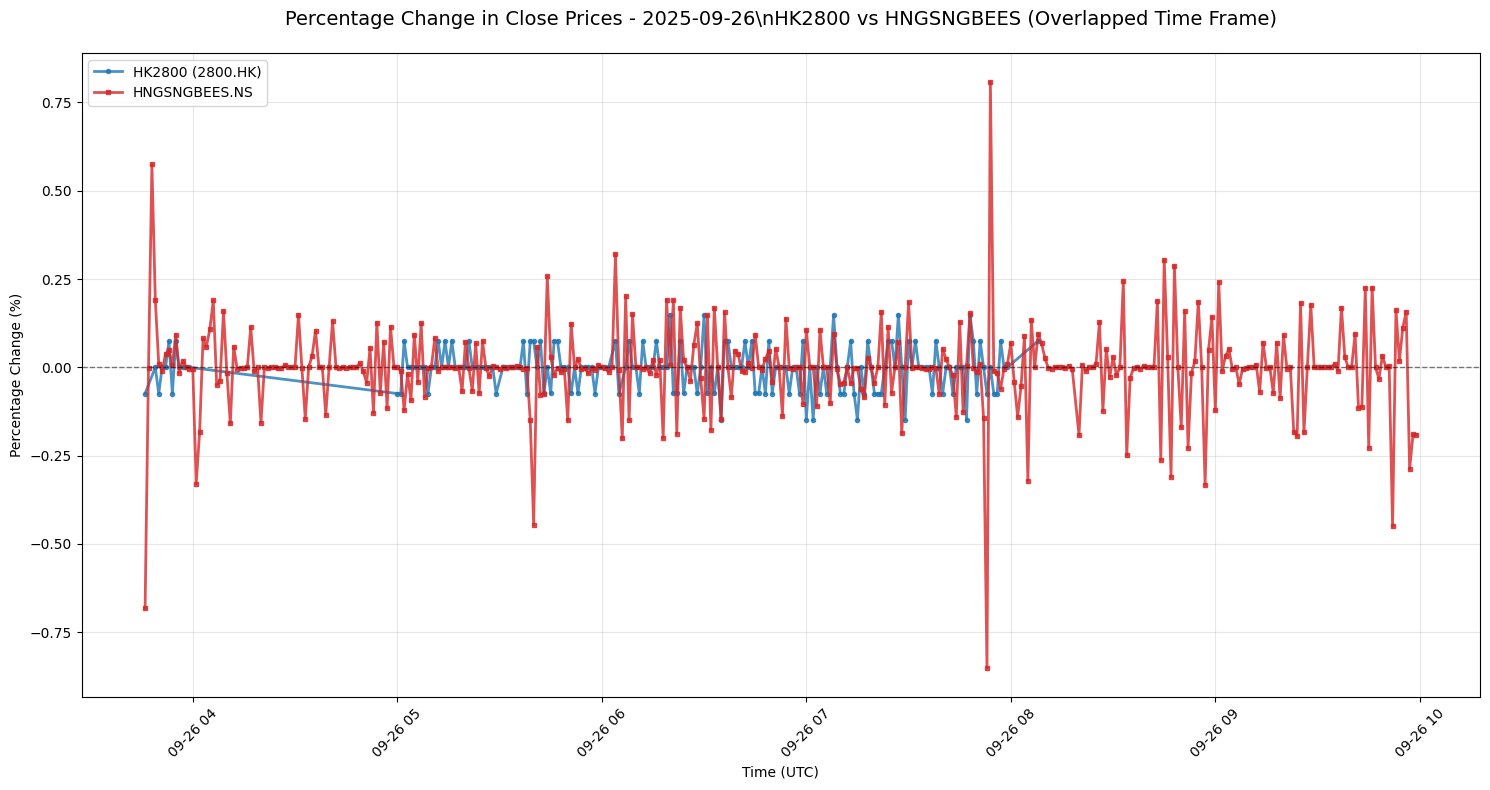

\nDaily correlation (2025-09-26): 0.0631
HK2800 stats for 2025-09-26: Mean=-0.0039%, Std=0.0596%, Data points=191
HNGSNGBEES stats for 2025-09-26: Mean=-0.0018%, Std=0.1273%, Data points=374


In [4]:
# Step 4: Interactive daily percentage change plotting function
def plot_daily_pct_changes(plot_date):
    """
    Plot percentage changes for a specific date
    
    Parameters:
    plot_date (str): Date in format 'YYYY-MM-DD' (e.g., '2025-09-26')
    """
    try:
        # Convert input date to datetime
        target_date = pd.to_datetime(plot_date).date()
        
        # Calculate percentage changes for entire overlapping period
        hk2800_pct_change = hk2800_overlap['Close'].pct_change() * 100
        hngsngbees_pct_change = hngsngbees_overlap['Close'].pct_change() * 100
        
        # Filter data for the specific date
        hk2800_daily = hk2800_pct_change[hk2800_pct_change.index.date == target_date]
        hngsngbees_daily = hngsngbees_pct_change[hngsngbees_pct_change.index.date == target_date]
        
        if len(hk2800_daily) == 0 and len(hngsngbees_daily) == 0:
            print(f"No data found for date: {plot_date}")
            print("Available dates in overlapping period:")
            unique_dates = sorted(set(list(hk2800_overlap.index.date) + list(hngsngbees_overlap.index.date)))
            for date in unique_dates:
                print(f"  {date}")
            return
        
        # Create the plot
        plt.figure(figsize=(15, 8))
        
        if len(hk2800_daily) > 0:
            plt.plot(hk2800_daily.index, hk2800_daily, color='tab:blue', 
                    label='HK2800 (2800.HK)', linewidth=2, alpha=0.8, marker='o', markersize=3)
        
        if len(hngsngbees_daily) > 0:
            plt.plot(hngsngbees_daily.index, hngsngbees_daily, color='tab:red', 
                    label='HNGSNGBEES.NS', linewidth=2, alpha=0.8, marker='s', markersize=3)
        
        plt.xlabel('Time (UTC)')
        plt.ylabel('Percentage Change (%)')
        plt.title(f'Percentage Change in Close Prices - {plot_date}\\nHK2800 vs HNGSNGBEES (Overlapped Time Frame)', 
                 fontsize=14, pad=20)
        plt.legend(loc='upper left')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # Add horizontal line at zero
        plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)
        
        plt.show()
        
        # Calculate daily statistics
        if len(hk2800_daily) > 0 and len(hngsngbees_daily) > 0:
            # Align the data for correlation calculation
            aligned_data = pd.DataFrame({
                'HK2800': hk2800_daily,
                'HNGSNGBEES': hngsngbees_daily
            }).dropna()
            
            if len(aligned_data) > 1:
                correlation = aligned_data['HK2800'].corr(aligned_data['HNGSNGBEES'])
                print(f"\\nDaily correlation ({plot_date}): {correlation:.4f}")
            else:
                print(f"\\nInsufficient overlapping data points for correlation calculation")
        
        # Print statistics
        if len(hk2800_daily) > 0:
            print(f"HK2800 stats for {plot_date}: Mean={hk2800_daily.mean():.4f}%, Std={hk2800_daily.std():.4f}%, Data points={len(hk2800_daily)}")
        
        if len(hngsngbees_daily) > 0:
            print(f"HNGSNGBEES stats for {plot_date}: Mean={hngsngbees_daily.mean():.4f}%, Std={hngsngbees_daily.std():.4f}%, Data points={len(hngsngbees_daily)}")
            
    except Exception as e:
        print(f"Error plotting data for {plot_date}: {str(e)}")

# Show available dates first
print("Available dates in the overlapping period:")
unique_dates = sorted(set(list(hk2800_overlap.index.date) + list(hngsngbees_overlap.index.date)))
for date in unique_dates:
    print(f"  {date}")

print("\\n" + "="*50)
print("USAGE: Call plot_daily_pct_changes('YYYY-MM-DD')")
print("Example: plot_daily_pct_changes('2025-09-26')")
print("="*50)

# Example: Plot for the first available date
if unique_dates:
    example_date = str(unique_dates[0])
    print(f"\\nExample plot for {example_date}:")
    plot_daily_pct_changes(example_date)